## 3D visualization of transit network

### the case of Zachary's Karate Club (ZKC) graph

Reference: [Deepnote](https://deepnote.com/@deepnote/3D-network-visualisations-using-plotly-a18c5e37-a517-4b27-bfde-1fee94a5760f)

In [9]:
#Import the required packages
import networkx as nx 
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#Let's import the ZKC graph:
ZKC_graph = nx.karate_club_graph()
#Let's keep track of which nodes represent John A and Mr Hi
Mr_Hi = 0
John_A = 33
#remember the number of nodes since this will come in useful later
Num_nodes = 34

#get the club labels - i.e. which club each individual ended up joining
club_labels = list(nx.get_node_attributes(ZKC_graph,'club').values())

In [4]:
#communities from last time - one list for each community
community_0 = [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
community_1 = [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 19, 21]
#label for each node corresponds to community 0 or community 1
community_label = [1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [5]:
#Let's opt for a spring layout
spring_pos = nx.spring_layout(ZKC_graph, seed=2) 

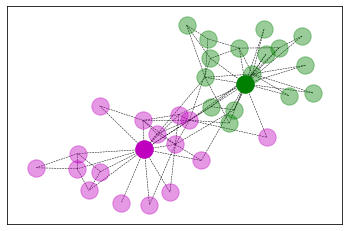

In [10]:
#draw the network
nx.draw_networkx_nodes(ZKC_graph, spring_pos, nodelist=community_0, node_color='g', alpha=0.4)
nx.draw_networkx_nodes(ZKC_graph, spring_pos, nodelist=community_1, node_color='m', alpha=0.4)

#let's highlight Mr Hi (solid purple) and John A (solid green)
nx.draw_networkx_nodes(ZKC_graph, spring_pos, nodelist=[John_A], node_color='g', alpha=1)
nx.draw_networkx_nodes(ZKC_graph, spring_pos, nodelist=[Mr_Hi], node_color='m', alpha=1)

nx.draw_networkx_edges(ZKC_graph, spring_pos, style='dashed',width = 0.5)
plt.show()

### Plotly 3D plot

In [12]:
#As before we use networkx to determine node positions. We want to do the same spring layout but in 3D
spring_3D = nx.spring_layout(ZKC_graph,dim=3, seed=18)
#an example node coordinate
spring_3D[4]

array([-0.25910334, -0.58293508,  0.72821969])

In [13]:
#we need to seperate the X,Y,Z coordinates for Plotly
x_nodes = [spring_3D[i][0] for i in range(Num_nodes)]# x-coordinates of nodes
y_nodes = [spring_3D[i][1] for i in range(Num_nodes)]# y-coordinates
z_nodes = [spring_3D[i][2] for i in range(Num_nodes)]# z-coordinates

In [15]:
#We also need a list of edges to include in the plot
edge_list = ZKC_graph.edges()
edge_list

EdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)])

In [16]:
#we  need to create lists that contain the starting and ending coordinates of each edge.
x_edges=[]
y_edges=[]
z_edges=[]

#need to fill these with all of the coordiates
for edge in edge_list:
    #format: [beginning,ending,None]
    x_coords = [spring_3D[edge[0]][0],spring_3D[edge[1]][0],None]
    x_edges += x_coords
    y_coords = [spring_3D[edge[0]][1],spring_3D[edge[1]][1],None]
    y_edges += y_coords
    z_coords = [spring_3D[edge[0]][2],spring_3D[edge[1]][2],None]
    z_edges += z_coords

In [17]:
#create a trace for the edges
trace_edges = go.Scatter3d(x=x_edges,
                        y=y_edges,
                        z=z_edges,
                        mode='lines',
                        line=dict(color='black', width=2),
                        hoverinfo='none')

In [18]:
#create a trace for the nodes
trace_nodes = go.Scatter3d(x=x_nodes,
                         y=y_nodes,
                        z=z_nodes,
                        mode='markers',
                        marker=dict(symbol='circle',
                                    size=10,
                                    color=community_label, #color the nodes according to their community
                                    colorscale=['lightgreen','magenta'], #either green or mageneta
                                    line=dict(color='black', width=0.5)),
                        text=club_labels,
                        hoverinfo='text')

To clearly highlight Mr Hi and John A. We need to plot their nodes again in another colour. The simplest way to do this is to create another trace for each node. These will then be plotted on top of the other nodes.

In [19]:
trace_MrHi = go.Scatter3d(x=[x_nodes[Mr_Hi]],
                    y=[y_nodes[Mr_Hi]],
                    z=[z_nodes[Mr_Hi]],
                    mode='markers',
                    name='Mr_Hi',
                    marker=dict(symbol='circle',
                                size=10,
                                color='darkmagenta',
                                line=dict(color='black', width=0.5)
                                ),
                    text = ['Mr_Hi'],
                    hoverinfo = 'text')

In [20]:
trace_JohnA = go.Scatter3d(x=[x_nodes[John_A]],
                        y=[y_nodes[John_A]],
                        z=[z_nodes[John_A]],
                        mode='markers',
                        name='John_A',
                        marker=dict(symbol='circle',
                                    size=10,
                                    color='green',
                                    line=dict(color='black', width=0.5)
                                    ),
                        text = ['Officer'],
                        hoverinfo = 'text')

In [21]:
#we need to set the axis for the plot 
axis = dict(showbackground=False,
            showline=False,
            zeroline=False,
            showgrid=False,
            showticklabels=False,
            title='')

In [22]:
#also need to create the layout for our plot
layout = go.Layout(title="Two Predicted Factions of Zachary's Karate Club",
                width=650,
                height=625,
                showlegend=False,
                scene=dict(xaxis=dict(axis),
                        yaxis=dict(axis),
                        zaxis=dict(axis),
                        ),
                margin=dict(t=100),
                hovermode='closest')

In [26]:
%matplotlib inline

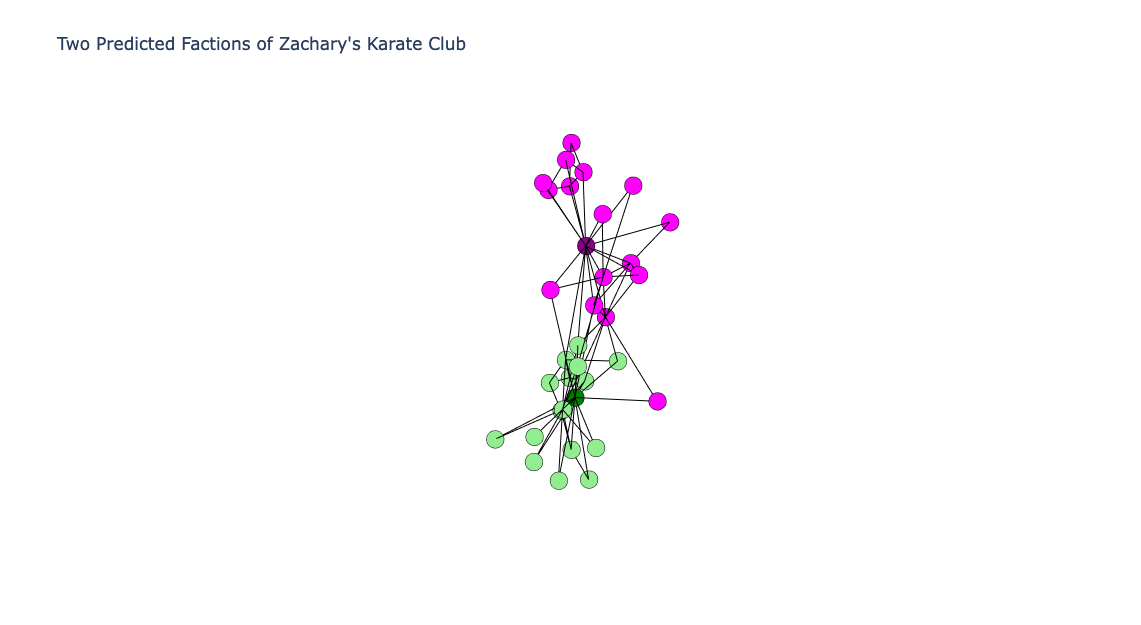

In [27]:
#Include the traces we want to plot and create a figure
data = [trace_edges, trace_nodes, trace_MrHi, trace_JohnA]
fig = go.Figure(data=data, layout=layout)

fig

## Task: print a simplified transit network network over 3D
1. Three transit lines (two horizontal lines, one vertical line)
2. Each line has one bus looping around the line
3. Bus travel speed is 1 unit per minute
4. 20 minutes are built in the time dimension

Task: build 3d map for visualization...

In [54]:
line1_stops = [(i, 1) for i in range(-3, 4, 1)]
line2_stops = [(i, 0) for i in range(-2, 2, 1)]
line3_stops = [(0, j) for j in range(-2, 2, 1)]

In [55]:
def plot_line(stops_coords, ax, fmt='b+-', label=""):
    xs = [coord[0] for coord in stops_coords]
    ys = [coord[1] for coord in stops_coords]
    plt.plot(xs, ys, fmt, label=label)

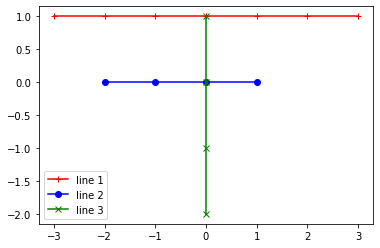

In [56]:
fig, ax = plt.subplots(1, 1)
plot_line(line1_stops, ax, fmt='r+-', label="line 1")
plot_line(line2_stops, ax, fmt='bo-', label="line 2")
plot_line(line3_stops, ax, fmt='gx-', label="line 3")
plt.legend()
plt.show()

In [ ]:
# from time 0-10, generate nodes for each minute

In [ ]:
# define vehicle looping on each line
class bus:
    def __init__(self, line, origin_coords):
        self.line = line
        self.origin = origin_coords
        self.run_t = 0
    def get_(self):
        pass
    